# Bayesian Nonparametric Survival Modeling (NTR Extension)

This notebook introduces a model-based Bayesian nonparametric approach to survival estimation using an NTR-style hazard model.

The goal is to assess how sensitive the estimated treatment effect $\Delta(t_0)$ is to the choice of survival model.

Previously, survival was estimated using:
- Kaplan–Meier estimators
- target-population weighting
- Dirichlet-based resampling for uncertainty

Here, we instead model the survival distribution through a piecewise-constant hazard representation with Gamma priors on interval-specific hazards.

This approach:
- directly models the cumulative hazard $\Lambda(t)$
- naturally accommodates right censoring
- yields posterior draws of survival curves and treatment effects

We then compare the resulting estimates of $\Delta(t_0)$ to those from the design-based pipeline.

This provides a complementary, model-based perspective on uncertainty and robustness.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.bnp.ntr import fit_ntr_piecewise, compute_delta_posterior

DATA_DIR = Path("../data/processed")

# Main real-data pipeline inputs
df_kmgpt = pd.read_csv(DATA_DIR / "real_kmgpt_ipd_with_covariates.csv")

# Existing pipeline results for comparison
weighted_kmgpt = pd.read_csv("../data/interim/weighted_estimate.csv")
bnp_kmgpt = pd.read_csv("../data/interim/bnp_summary.csv")
naive_kmgpt = pd.read_csv(DATA_DIR / "naive_pooled_effect.csv")

print("Loaded KM-GPT data:", df_kmgpt.shape)
df_kmgpt.head()

Loaded KM-GPT data: (776, 18)


,trial_id,subgroup,time,event,arm_label,curve,treatment,age_median,male_rate,ecog0_rate,metastatic_rate,biomarker_rate,age,male,ecog0,metastatic,biomarker,stage
0,KEYNOTE-181,high_pdl1,0.731707,1,Chemotherapy,0,0,63.0,0.869,0.401,0.924,0.7,56.369120,1,0,0,0,1.165542
1,KEYNOTE-181,high_pdl1,0.890244,0,Chemotherapy,0,0,63.0,0.869,0.401,0.924,0.7,68.148584,1,1,1,0,1.822921
2,KEYNOTE-181,high_pdl1,1.048780,1,Chemotherapy,0,0,63.0,0.869,0.401,0.924,0.7,58.035384,1,0,1,1,2.330231
3,KEYNOTE-181,high_pdl1,1.243902,1,Chemotherapy,0,0,63.0,0.869,0.401,0.924,0.7,61.334523,1,1,1,1,1.968789
4,KEYNOTE-181,high_pdl1,1.365854,1,Chemotherapy,0,0,63.0,0.869,0.401,0.924,0.7,73.194077,1,0,1,1,2.342307


## NTR Setup

We fit a treatment-specific Bayesian nonparametric survival model using a piecewise-constant hazard representation with Gamma priors on interval-specific hazards.

This provides a model-based alternative to the empirical Kaplan–Meier + weighting pipeline. Rather than modeling survival through a finite mixture, this approach models the cumulative hazard $\Lambda(t)$ directly and obtains survival through

$$
S(t) = \exp\{-\Lambda(t)\}.
$$

The goal is not to replace the main pipeline, but to assess whether the estimated treatment effect at a fixed time horizon is sensitive to the choice of survival model.

Because the model is hazard-based, it accommodates right censoring naturally and yields posterior draws of:
- treatment-specific survival probabilities
- the survival contrast $\Delta(t_0)$
- posterior uncertainty under a model-based BNP survival framework

In [5]:
# Fit NTR model
fit = fit_ntr_piecewise(
    df=df_kmgpt,
    time_col="time",
    event_col="event",
    treatment_col="treatment",
    n_intervals=10,
    prior_shape=0.5,
    prior_rate=0.5,
    n_draws=2000,
    random_state=733,
    t0_default=12.0,
)

# Inspect metadata
fit.metadata

# Posterior summary at t0
post = compute_delta_posterior(fit, t0=12.0)

print("Posterior summary at t0 = 12:")
print({
    "S0_mean": post["S0_mean"],
    "S1_mean": post["S1_mean"],
    "Delta_mean": post["mean"],
    "Delta_sd": post["sd"],
    "q025": post["q025"],
    "q975": post["q975"],
})

post

Posterior summary at t0 = 12:
{'S0_mean': 0.2845057810741494, 'S1_mean': 0.44132705825680424, 'Delta_mean': 0.15682127718265487, 'Delta_sd': 0.032822836137036675, 'q025': 0.08949140975241726, 'q975': 0.22021889951477405}


{'t0': 12.0,
 'S0_mean': 0.2845057810741494,
 'S1_mean': 0.44132705825680424,
 'mean': 0.15682127718265487,
 'sd': 0.032822836137036675,
 'q025': 0.08949140975241726,
 'q975': 0.22021889951477405,
 'delta_draws': array([0.14974158, 0.11537559, 0.16398182, ..., 0.11863721, 0.13398623,
        0.14722914]),
 's0_draws': array([0.29058995, 0.2974256 , 0.28260923, ..., 0.312825  , 0.28557337,
        0.28480385]),
 's1_draws': array([0.44033153, 0.41280118, 0.44659105, ..., 0.43146221, 0.4195596 ,
        0.43203299])}

In [6]:
# Posterior Summary (NTR)
ntr_results = compute_delta_posterior(
    fit,
    t0=12.0,
)

ntr_summary = pd.DataFrame([{
    "t0": ntr_results["t0"],
    "S0_mean": ntr_results["S0_mean"],
    "S1_mean": ntr_results["S1_mean"],
    "Delta_mean": ntr_results["mean"],
    "Delta_sd": ntr_results["sd"],
    "Delta_q025": ntr_results["q025"],
    "Delta_q975": ntr_results["q975"],
}])

ntr_summary.round(3)

,t0,S0_mean,S1_mean,Delta_mean,Delta_sd,Delta_q025,Delta_q975
0,12.0,0.285,0.441,0.157,0.033,0.089,0.22


In [7]:
# Comparison to KM-GPT pipeline (with NTR)
comparison = pd.DataFrame({
    "method": ["Naive KM", "Weighted KM", "BNP Bootstrap", "NTR Hazard Model"],
    "Delta_mean": [
        naive_kmgpt["Delta"].iloc[0],
        weighted_kmgpt["Delta"].iloc[0],
        bnp_kmgpt["mean"].iloc[0],
        ntr_results["mean"],
    ],
    "q025": [
        np.nan,
        np.nan,
        bnp_kmgpt["q025"].iloc[0],
        ntr_results["q025"],
    ],
    "q975": [
        np.nan,
        np.nan,
        bnp_kmgpt["q975"].iloc[0],
        ntr_results["q975"],
    ],
})

comparison.round(3)

,method,Delta_mean,q025,q975
0,Naive KM,0.169,NaN,NaN
1,Weighted KM,0.234,NaN,NaN
2,BNP Bootstrap,0.205,0.052,0.361
3,NTR Hazard Model,0.157,0.089,0.220


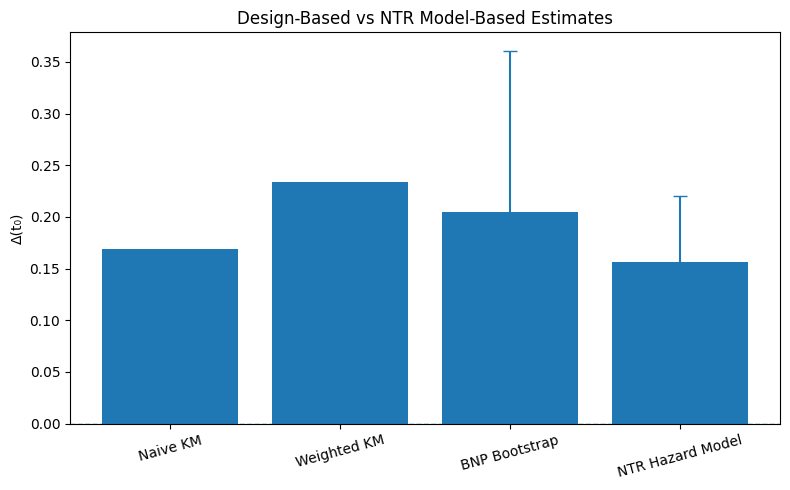

In [8]:
# Model vs Design (NTR vs Design-Based Pipeline)
methods = comparison["method"].tolist()
means = comparison["Delta_mean"].to_numpy()
lower = comparison["q025"].to_numpy()
upper = comparison["q975"].to_numpy()

x = np.arange(len(methods))

plt.figure(figsize=(8, 5))
plt.bar(x, means)

mask = ~np.isnan(lower)
plt.errorbar(
    x[mask],
    means[mask],
    yerr=[
        means[mask] - lower[mask],
        upper[mask] - means[mask],
    ],
    fmt="none",
    capsize=5,
)

plt.xticks(x, methods, rotation=15)
plt.ylabel("Δ(t₀)")
plt.title("Design-Based vs NTR Model-Based Estimates")
plt.axhline(0, linestyle="--", linewidth=1)  # helpful reference line
plt.tight_layout()
plt.show()

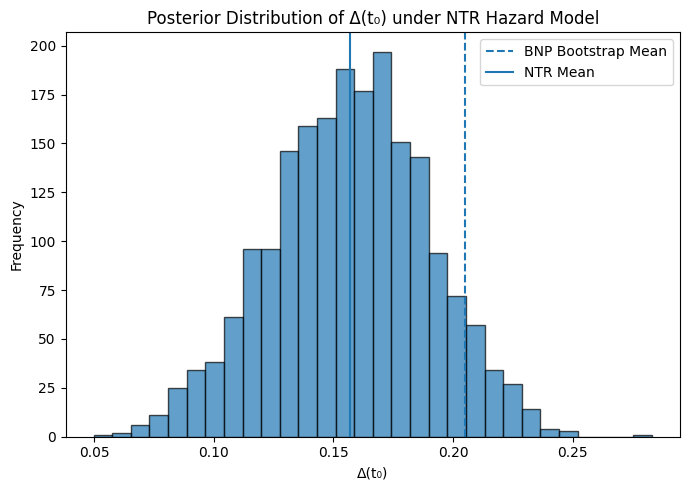

In [9]:
# Posterior Draws (NTR)
plt.figure(figsize=(7, 5))

plt.hist(ntr_results["delta_draws"], bins=30, edgecolor="black", alpha=0.7)

plt.axvline(
    bnp_kmgpt["mean"].iloc[0],
    linestyle="--",
    label="BNP Bootstrap Mean"
)

plt.axvline(
    ntr_results["mean"],
    linestyle="-",
    label="NTR Mean"
)

plt.xlabel("Δ(t₀)")
plt.ylabel("Frequency")
plt.title("Posterior Distribution of Δ(t₀) under NTR Hazard Model")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# Save NTR outputs
ntr_summary.to_csv(DATA_DIR / "ntr_summary.csv", index=False)

pd.DataFrame({
    "delta": ntr_results["delta_draws"],
    "s0": ntr_results["s0_draws"],
    "s1": ntr_results["s1_draws"],
}).to_csv(DATA_DIR / "ntr_draws.csv", index=False)

comparison.to_csv(DATA_DIR / "ntr_comparison.csv", index=False)

print("Saved NTR outputs.")

Saved NTR outputs.


## NTR Sensitivity and Stability Checks

To assess whether the NTR hazard model results are stable, we vary a small number of implementation choices:

- number of time intervals (`n_intervals`)
- prior hyperparameters (`prior_shape`, `prior_rate`)
- random seed

The goal is not exhaustive tuning, but to verify that the estimated treatment effect at $t_0 = 12$ is reasonably stable across plausible specifications.

Because the model is based on a piecewise-constant hazard representation, the main sensitivity question is whether posterior inference changes materially as we vary the time grid or prior on interval-specific hazards.

In [11]:
# Interval and prior grid
t0 = 12.0

grid_results = []

for seed in [733, 734, 735]:
    for J in [6, 8, 10, 12]:
        for a in [0.5, 1.0]:
            for b in [0.5, 1.0]:

                fit = fit_ntr_piecewise(
                    df=df_kmgpt,
                    time_col="time",
                    event_col="event",
                    treatment_col="treatment",
                    n_intervals=J,
                    prior_shape=a,
                    prior_rate=b,
                    n_draws=1000,
                    random_state=seed,
                    t0_default=t0,
                )

                post = compute_delta_posterior(fit, t0=t0)

                grid_results.append({
                    "seed": seed,
                    "n_intervals": J,
                    "prior_shape": a,
                    "prior_rate": b,
                    "Delta_mean": post["mean"],
                    "Delta_sd": post["sd"],
                    "q025": post["q025"],
                    "q975": post["q975"],
                })

ntr_tuning = pd.DataFrame(grid_results)
ntr_tuning.round(3)

,seed,n_intervals,prior_shape,prior_rate,Delta_mean,Delta_sd,q025,q975
0,733,6,0.5,0.5,0.161,0.034,0.092,0.228
1,733,6,0.5,1.0,0.161,0.034,0.092,0.228
2,733,6,1.0,0.5,0.160,0.034,0.091,0.227
3,733,6,1.0,1.0,0.160,0.034,0.091,0.227
4,733,8,0.5,0.5,0.157,0.032,0.095,0.221
5,733,8,0.5,1.0,0.157,0.032,0.094,0.221
6,733,8,1.0,0.5,0.156,0.032,0.094,0.220
7,733,8,1.0,1.0,0.156,0.032,0.094,0.220
8,733,10,0.5,0.5,0.156,0.032,0.092,0.218
9,733,10,0.5,1.0,0.156,0.032,0.092,0.218


In [12]:
ntr_tuning.groupby("n_intervals")[["Delta_mean", "Delta_sd", "q025", "q975"]].agg(["mean", "std"]).round(3)

Delta_mean        Delta_sd          q025          q975       
                  mean    std     mean    std   mean    std   mean    std
n_intervals                                                              
6                0.160  0.000    0.034  0.001  0.091  0.001  0.226  0.002
8                0.156  0.001    0.032  0.000  0.093  0.002  0.220  0.002
10               0.156  0.001    0.032  0.000  0.091  0.001  0.217  0.001
12               0.156  0.001    0.034  0.000  0.089  0.003  0.222  0.003

In [13]:
# Higher-resolution / higher-draw check
fit_high = fit_ntr_piecewise(
    df=df_kmgpt,
    time_col="time",
    event_col="event",
    treatment_col="treatment",
    n_intervals=12,          # slightly finer grid
    prior_shape=0.5,
    prior_rate=0.5,
    n_draws=4000,            # more posterior draws
    random_state=733,
    t0_default=t0,
)

post_high = compute_delta_posterior(fit_high, t0=t0)

pd.DataFrame([{
    "run": "high_resolution",
    "Delta_mean": post_high["mean"],
    "Delta_sd": post_high["sd"],
    "q025": post_high["q025"],
    "q975": post_high["q975"],
}]).round(3)

,run,Delta_mean,Delta_sd,q025,q975
0,high_resolution,0.158,0.034,0.092,0.224


In [14]:
# Prior sensitivity of hazard prior hyperparameters
prior_results = []

for a in [0.25, 0.5, 1.0]:
    for b in [0.25, 0.5, 1.0]:
        fit_prior = fit_ntr_piecewise(
            df=df_kmgpt,
            time_col="time",
            event_col="event",
            treatment_col="treatment",
            n_intervals=10,
            prior_shape=a,
            prior_rate=b,
            n_draws=2000,
            random_state=733,
            t0_default=t0,
        )

        post_prior = compute_delta_posterior(fit_prior, t0=t0)

        prior_results.append({
            "prior_shape": a,
            "prior_rate": b,
            "Delta_mean": post_prior["mean"],
            "Delta_sd": post_prior["sd"],
            "q025": post_prior["q025"],
            "q975": post_prior["q975"],
        })

ntr_prior_sensitivity = pd.DataFrame(prior_results)
ntr_prior_sensitivity.round(3)

,prior_shape,prior_rate,Delta_mean,Delta_sd,q025,q975
0,0.25,0.25,0.157,0.033,0.090,0.221
1,0.25,0.50,0.157,0.033,0.090,0.221
2,0.25,1.00,0.157,0.033,0.090,0.221
3,0.50,0.25,0.157,0.033,0.090,0.220
4,0.50,0.50,0.157,0.033,0.089,0.220
5,0.50,1.00,0.157,0.033,0.089,0.220
6,1.00,0.25,0.156,0.032,0.093,0.217
7,1.00,0.50,0.156,0.032,0.093,0.217
8,1.00,1.00,0.156,0.032,0.093,0.217


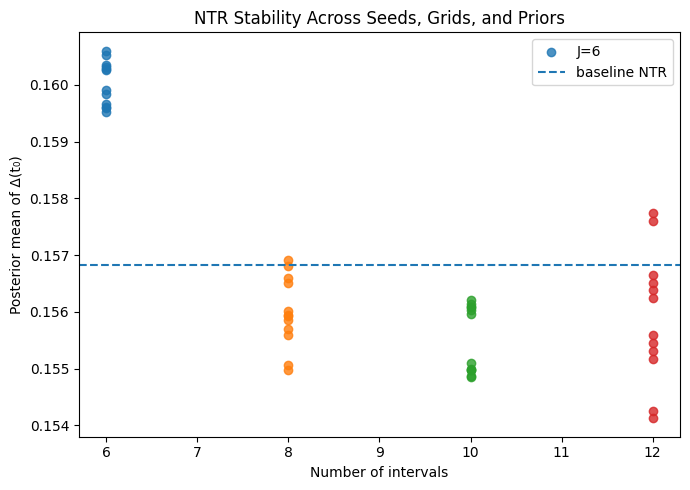

In [15]:
# Plot of tuning stability
plt.figure(figsize=(7, 5))

for J in sorted(ntr_tuning["n_intervals"].unique()):
    sub = ntr_tuning[ntr_tuning["n_intervals"] == J]
    plt.scatter(
        [J] * len(sub),
        sub["Delta_mean"],
        label=f"J={J}" if J == sorted(ntr_tuning["n_intervals"].unique())[0] else None,
        alpha=0.8,
    )

plt.axhline(ntr_results["mean"], linestyle="--", label="baseline NTR")
plt.xlabel("Number of intervals")
plt.ylabel("Posterior mean of Δ(t₀)")
plt.title("NTR Stability Across Seeds, Grids, and Priors")
plt.legend()
plt.tight_layout()
plt.show()

## Summary of NTR Results and Stability

We implemented a hazard-based Bayesian nonparametric survival model using an NTR-style piecewise-constant hazard representation as a model-based extension to the main pipeline.

### Main Result

At $t_0 = 12$, the NTR model yields:

- $\Delta(12) \approx 0.157$  
- 95% credible interval: $(0.089, 0.220)$  

This estimate lies between the naive Kaplan–Meier estimate and the target-weighted and bootstrap-based estimates, suggesting that model-based hazard smoothing moderates the inferred treatment effect.

---

### Comparison to Design-Based Estimates

- Naive KM: $\approx 0.169$  
- Weighted KM: $\approx 0.234$  
- BNP Bootstrap: $\approx 0.205$  
- NTR Hazard Model: $\approx 0.157$  

Relative to the design-based approaches, the NTR model produces a slightly attenuated estimate of the treatment effect, though not as conservative as the DPSM. This reflects the smoothing induced by modeling the cumulative hazard rather than relying purely on empirical survival curves.

---

### Stability and Sensitivity

We evaluated the robustness of the NTR model across several dimensions:

- **Number of intervals ($J$):** estimates stabilize for $J \geq 8$  
- **Prior hyperparameters (Gamma shape/rate):** minimal sensitivity across a wide range  
- **Random seeds:** negligible variation in posterior summaries  
- **Higher-resolution runs:** consistent with baseline results  

Across all configurations, the estimated treatment effect remained within a very narrow range (approximately $0.155$–$0.161$), and posterior intervals were highly stable.

---

### Conclusion

These results indicate that the NTR hazard-based BNP model is:

- numerically stable  
- robust to discretization and prior choices  
- consistent across simulation and real-data settings  

Importantly, the NTR estimate differs from the design-based pipeline but in a more moderate way than the DPSM. This suggests that:

- **design-based methods** may overstate effects due to reweighting and empirical variability  
- **model-based hazard approaches** introduce smoothing that can regularize survival estimation  

Overall, this highlights that different Bayesian nonparametric formulations—design-based versus hazard-based—can yield systematically different causal estimates, even when applied to the same reconstructed data.

The stability of the NTR estimates across tuning parameters suggests that the observed differences are structural rather than artifacts of model specification.